In [97]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [4]:
snapnum = 99
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
halo_path = f"{basePath}/files/disperse"
fname_halo = f"{halo_path}/disperse_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [6]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [7]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [8]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [137]:
d_minima = np.log10(f["d_minima"])
d_minima_cent = d_minima[halos["GroupFirstSub"]]

In [85]:
d_node = np.log10(f["d_node"])
d_node_cent = d_node[halos["GroupFirstSub"]]

In [172]:
d_skel = np.log10(f["d_skel"])
d_skel_cent = d_minima[halos["GroupFirstSub"]]

In [100]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [101]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [ ]:
plt.scatter(d_skel_cent, cent_sfrs, s=0.1)
plt.ylabel(r"$\rm log_{10}(SFR [M_\odot yr^{-1}])$")
plt.xlabel("d_skel")

In [86]:
logM = 11
mask = (mvir > logM) & (mvir < logM + 0.1)

In [222]:
stats.spearmanr(d_node_cent[mask], cent_sfrs[mask])

SpearmanrResult(correlation=0.008383816140340481, pvalue=0.08773284443843916)

Text(0.5, 0, 'd_skel')

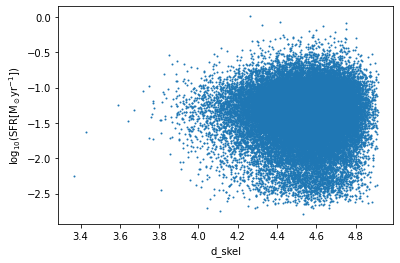

In [223]:
plt.scatter(d_node_cent[mask], cent_sfrs[mask], s=1)
plt.ylabel(r"$\rm log_{10}(SFR [M_\odot yr^{-1}])$")
plt.xlabel("d_skel")

In [12]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [110]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [14]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [119]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [120]:
sum_sfrs = np.zeros(len(mvir))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [23]:
d_node = np.log10(f["d_node"])
d_node_sat = d_node[~cent_mask_all]

In [106]:
node_avs1 = np.add.reduceat(d_node_sat, indices)

In [112]:
node_avs = np.zeros(len(mvir))
node_avs[unique_ids] = node_avs1
node_avs /= (halos["GroupNsubs"]-1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


In [42]:
mstar = subhalos["SubhaloMassType"][:,4]*1e10

In [91]:
mstar_cent1 = mstar[cent_mask_all]
mstar_cent = np.zeros(len(mvir))
mstar_cent[halos["GroupFirstSub"]>-1] = mstar_cent1

In [43]:
mstar_sat = mstar[~cent_mask_all]

In [79]:
mask_sat = np.log10(mstar_sat) > 10

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [92]:
mask_cent = np.log10(mstar_cent) > 10

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [45]:
ssfr = subhalos["SubhaloSFR"]/mstar

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [93]:
ssfr_cent1 = ssfr[cent_mask_all]
ssfr_cent = np.zeros(len(mvir))
ssfr_cent[halos["GroupFirstSub"]>-1] = ssfr_cent1

In [46]:
ssfr_sat = ssfr[~cent_mask_all]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


(1.0, 4.0)

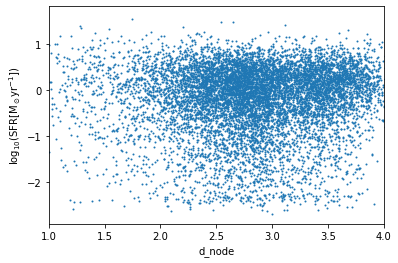

In [41]:
plt.scatter(d_node_sat[mask_sat], np.log10(sat_sfrs[mask_sat]), s=1)
plt.ylabel(r"$\rm log_{10}(SFR [M_\odot yr^{-1}])$")
plt.xlabel("d_node")
plt.xlim(1,4)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


(1.0, 4.0)

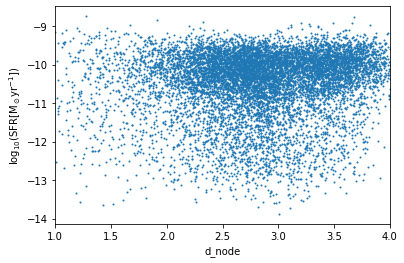

In [47]:
plt.scatter(d_node_sat[mask_sat], np.log10(ssfr_sat[mask_sat]), s=1)
plt.ylabel(r"$\rm log_{10}(SFR [M_\odot yr^{-1}])$")
plt.xlabel("d_node")
plt.xlim(1,4)

In [70]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1, xmin =0):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>xmin]))/dx)
    
    
    bin_first = min(xdata[xdata>xmin]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        # print(bin_max)
        # print(bin_min)
        # print(np.sum(bin_mask))
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.nanpercentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.nanmedian(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [78]:
np.sum(ssfr_sat[mask_sat] == 0)

17780

In [83]:
np.sum(ssfr_sat[mask_sat] > 0)

10135

In [80]:
percentiles_list = [25, 50, 75]
window_size=0.2
dx= 0.1

In [81]:
bin_cents_sat, percentiles_sat = running_percentiles(d_node_sat[mask_sat], np.log10(ssfr_sat[mask_sat]), window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


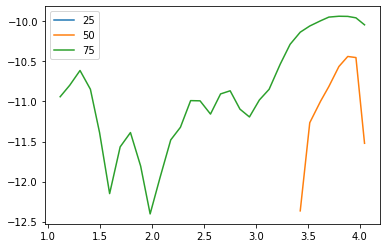

In [82]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_sat, percentiles_sat[ip], label=percentiles_list[ip])
    
plt.legend()

In [94]:
bin_cents_cent, percentiles_cent = running_percentiles(d_node_cent[mask_cent], np.log10(ssfr_cent[mask_cent]), window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


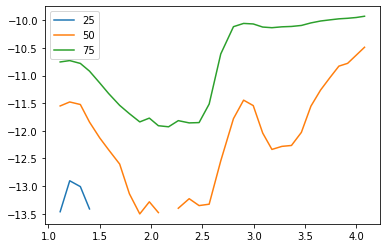

In [95]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_cent, percentiles_cent[ip], label=percentiles_list[ip])
    
plt.legend()

In [99]:
coef = stats.spearmanr(d_node_cent[mask_cent],ssfr_cent[mask_cent])[0]
print(coef)

0.1141580413560828


In [102]:
bin_cents_cent, percentiles_cent = running_percentiles(d_node_cent[mask_cent], np.log10(cent_sfrs[mask_cent]), window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


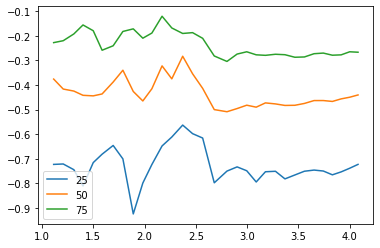

In [103]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_cent, percentiles_cent[ip], label=percentiles_list[ip])
    
plt.legend()

In [123]:
bin_cents_cent, percentiles_cent = running_percentiles(d_node_cent[mask_sum], np.log10(cent_sfrs[mask_sum]), window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.


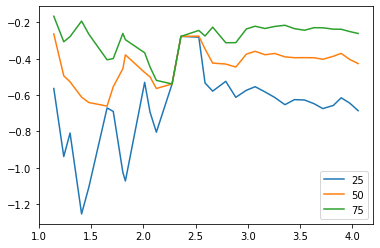

In [124]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_cent, percentiles_cent[ip], label=percentiles_list[ip])
    
plt.legend()

In [104]:
bin_cents_sat, percentiles_sat = running_percentiles(d_node_sat[mask_sat], np.log10(sat_sfrs[mask_sat]), window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


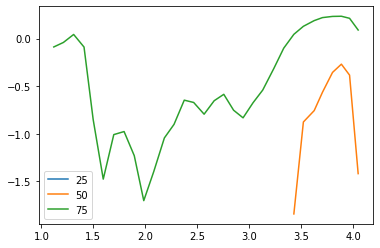

In [105]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_sat, percentiles_sat[ip], label=percentiles_list[ip])
    
plt.legend()

In [115]:
mask_sum = (mvir > 12) & (mvir < 12.1)

In [121]:
bin_cents_sat, percentiles_sat = running_percentiles(node_avs[mask_sum], sum_sfrs[mask_sum], window_size, percentiles=percentiles_list, dx=dx, xmin=1)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


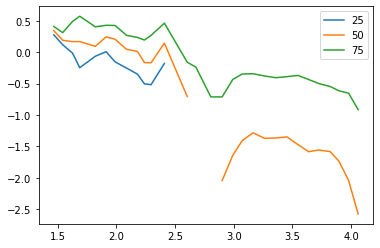

In [122]:
for ip in range(len(percentiles_list)):
    plt.plot(bin_cents_sat, percentiles_sat[ip], label=percentiles_list[ip])
    
plt.legend()